In [19]:
import pandas as pd
import numpy as np

In [20]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [21]:
df.shape

(10000, 14)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [25]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [26]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [27]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [28]:
df.drop(columns=["RowNumber",
                 "CustomerId",
                 "Surname"],
                 inplace=True)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [29]:
df = pd.get_dummies(
    df,
    columns=["Geography", "Gender"],
    drop_first=True,
    dtype=int
)

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [30]:
from sklearn.model_selection import train_test_split

X = df.drop(columns= ["Exited"])
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42,
                                                    test_size=0.2)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
import tensorflow


In [33]:
from keras.models import Sequential
from keras.layers import Input, Dense

model = Sequential()
model.add(Input(shape=(11,)))
model.add(Dense(11, activation="sigmoid"))
model.add(Dense(10, activation="sigmoid"))
model.add(Dense(1, activation="sigmoid"))

In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263 (1.03 KB)

 Trainable params: 263 (1.03 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [36]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100
)

Epoch 1/100


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.5101 - val_accuracy: 0.7987 - val_loss: 0.4901
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - loss: 0.4889 - val_accuracy: 0.7987 - val_loss: 0.4714
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - loss: 0.4704 - val_accuracy: 0.7987 - val_loss: 0.4502
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - accuracy: 0.7934 - loss: 0.4532 - val_accuracy: 0.7987 - val_loss: 0.4350
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - loss: 0.4414 - val_accuracy: 0.8031 - val_loss: 0.4259
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7975 - loss: 0.4349 - val_accuracy: 0.8150 - val_loss: 0.4210
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8075 - loss: 0.4313 - val_accuracy: 0.8188 - val_loss: 0.4186
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8095 - loss: 0.4295 - val_accuracy: 0.82

In [37]:
model.layers[1].get_weights()

[array([[ 0.34050772, -0.56358594, -1.2140385 ,  0.51341647,  0.8608567 ,
          0.59749806,  0.5017325 , -0.0116019 ,  1.2082639 , -0.22076991],
        [-0.9424007 ,  1.2104439 ,  0.33069822, -1.0552745 , -1.0545546 ,
         -0.52776355, -0.89293283, -1.132062  , -0.31749153, -0.68320054],
        [ 0.5172712 , -0.83596224, -0.39580396,  1.0197778 ,  0.3890357 ,
          1.3440443 ,  0.40653506,  0.48879012,  1.2628894 ,  0.9849628 ],
        [-0.04375235, -0.19717489, -0.01384884,  0.354264  ,  0.83786064,
          0.2854595 ,  0.39509666,  0.31078073,  0.22869705,  0.9869958 ],
        [ 0.46841556, -0.8224426 , -0.27353686,  0.69551   ,  0.580261  ,
          1.1511345 ,  0.70427597,  0.71564835,  1.06299   , -0.01188053],
        [-0.95412064,  0.9918561 ,  0.72590196, -1.3086569 , -0.9657874 ,
         -1.1650747 , -1.2530254 , -1.3365043 , -1.0569205 , -1.2918568 ],
        [ 0.7386983 , -0.62684214, -1.2717421 ,  0.376392  ,  0.75378996,
          1.0949448 ,  1.275011 

In [38]:
model.layers[0].get_weights()

[array([[ 0.00994268,  0.07070359, -0.14321819, -0.02122834,  0.41583982,
         -0.36276233, -0.05429947,  0.1994698 , -0.11323126,  0.05989695,
          0.17270772],
        [ 0.3060205 , -0.9278973 ,  0.03288072, -1.932802  ,  0.75519735,
          1.4539999 ,  0.31668323,  1.9820004 ,  0.64263594, -1.5717336 ,
         -1.2818065 ],
        [ 0.03966884, -0.01919158, -0.01081495,  0.11013919,  0.06250596,
          0.33551598, -0.01587363, -0.30097842,  0.03066347, -0.28000763,
          0.3843406 ],
        [-0.32618856, -0.08112672, -0.03288883, -0.01127782, -0.08812433,
         -0.18405692, -1.017272  ,  0.12332582,  1.368303  , -0.62323946,
         -1.246422  ],
        [-0.88585323, -2.9739158 , -1.1137514 , -0.34878522, -0.49436584,
          0.73583364, -0.7375645 ,  0.79452896,  3.2091634 , -0.5688145 ,
         -0.8554998 ],
        [-0.08102317, -0.25212702, -0.04634299, -0.1830674 ,  0.53081423,
          0.19836272, -0.08672077, -0.238044  , -0.1117189 , -0.5671971

In [39]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step


In [40]:
y_pred = np.where(y_log>0.5, 1, 0)

In [41]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,
               y_pred)

0.864

In [42]:
import matplotlib.pyplot as plt

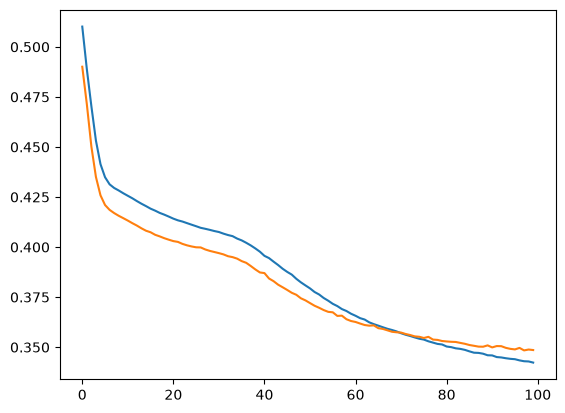

In [43]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

In [44]:
history.history

{'accuracy': [0.7934374809265137,
  0.7934374809265137,
  0.7934374809265137,
  0.7934374809265137,
  0.7934374809265137,
  0.7975000143051147,
  0.8075000047683716,
  0.8095312714576721,
  0.811718761920929,
  0.8165624737739563,
  0.8181250095367432,
  0.8190624713897705,
  0.8212500214576721,
  0.8221874833106995,
  0.8229687213897705,
  0.8257812261581421,
  0.8256250023841858,
  0.8268749713897705,
  0.8284375071525574,
  0.8292187452316284,
  0.8292187452316284,
  0.8303124904632568,
  0.8295312523841858,
  0.8315625190734863,
  0.8317187428474426,
  0.8310937285423279,
  0.8324999809265137,
  0.832812488079071,
  0.8332812786102295,
  0.8348437547683716,
  0.8335937261581421,
  0.8360937237739563,
  0.8359375,
  0.8349999785423279,
  0.8357812762260437,
  0.8373437523841858,
  0.8371875286102295,
  0.8370312452316284,
  0.8379687666893005,
  0.8384374976158142,
  0.839062511920929,
  0.8393750190734863,
  0.8404687643051147,
  0.8396875262260437,
  0.8409374952316284,
  0.842031